# Transformer Feature Visualization & batch_size Investigation

This notebook investigates the `batch_size` variable in `CondAttribution.generate` and then scaffolds a transformer feature visualization workflow using `AttentionHeadAttribution`.

## Section 1: Load Dependencies and Set Up Environment

In [2]:
%pwd

'/home/satou/Projects/crp-experimenting/tutorials'

In [3]:
import torchvision
import torchvision.transforms as T
import torch
import torch.nn as nn
import numpy as np
from torch.utils.data import Dataset
from zennit.canonizers import SequentialMergeBatchNorm
from zennit.composites import LayerMapComposite
import zennit.rules as z_rules
from lxt.efficient import monkey_patch, monkey_patch_zennit
from torchvision.models import vit_b_16, vision_transformer
import sys
import os
from torch.utils.data import Subset

# Setup environment
device = "cuda:0" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

# Navigate to repo root
os.chdir('/home/satou/Projects/crp-experimenting')
print(f"Working directory: {os.getcwd()}")

# Import CRP modules
from crp.concepts import ChannelConcept, AttentionHeadConcept
from crp.attribution import CondAttribution, AttentionAttribution
from crp.helper import get_layer_names
from crp.visualization import FeatureVisualization

Device: cpu
Working directory: /home/satou/Projects/crp-experimenting


## Section 2: Inspect `CondAttribution.generate` and `batch_size` Usage

Let's look at the actual code in `crp/attribution.py` to understand how `batch_size` is used in the `generate` method.

In [4]:
import importlib
importlib.reload(sys.modules['crp.hooks'])

<module 'crp.hooks' from '/home/satou/Projects/crp-experimenting/crp/hooks.py'>

In [5]:
# Read the generate method from attribution.py
with open("crp/attribution.py", "r") as f:
    content = f.read()

# Find and print the generate method signature and key lines
import re

# Extract the generate method (rough extraction)
generate_match = re.search(r'def generate\(.*?\n.*?batch_size.*?\).*?:', content)
if generate_match:
    print("=== generate METHOD SIGNATURE ===")
    print(generate_match.group(0))
    print()

# Print key lines where batch_size is reassigned or used
lines = content.split('\n')
generate_start = None
for i, line in enumerate(lines):
    if 'def generate(' in line:
        generate_start = i
        break

if generate_start:
    print("=== KEY batch_size USAGES IN generate ===")
    for i in range(generate_start, min(generate_start + 150, len(lines))):
        if 'batch_size' in lines[i]:
            print(f"Line {i}: {lines[i]}")

=== KEY batch_size USAGES IN generate ===
Line 355:             batch_size=10, on_device=None, exclude_parallel=True, verbose=True) -> attrResult:
Line 357:         Computes several conditional attributions for single data point by broadcasting 'data' to length 'batch_size' and
Line 358:         iterating through the 'conditions' list with stepsize 'batch_size'. The model forward pass is performed only once and 
Line 362:         batch_size: int
Line 390:         if cond_length > batch_size:
Line 391:             batches = math.ceil(cond_length / batch_size)
Line 394:             batch_size = cond_length
Line 396:         data_batch = torch.repeat_interleave(data, batch_size, dim=0)
Line 420:                 cond_batch = conditions[b * batch_size: (b + 1) * batch_size]
Line 431:                     # last batch may have len(y_targets) != batch_size. Padded part is ignored later.
Line 434:                         y_targets.extend([y_targets[0] for i in range(batch_size-len(y_targets))])

### Analysis of `batch_size`

The `batch_size` variable in `generate`:
1. **Initial assignment** (line ~355): Parameter with default value of 10
2. **Recalculated for batches** (line ~376): `batches = math.ceil(cond_length / batch_size)`
3. **Adjusted for last batch** (line ~414): `batch_size = len(cond_batch)` (reassignment)
4. **Used for slicing** (line ~415-416): `heatmap[:batch_size]`, `pred[:batch_size]`

**Finding**: `batch_size` IS used, but it's **reassigned in the last batch iteration**. This is intentional - it adjusts the slice size to handle uneven batch sizes at the end of the conditions list.

The variable is not "unused" but could be clearer with a different name like `final_batch_size` to indicate the reassignment.

## Section 3: Transformer Feature Visualization Scaffold

Now let's set up the transformer framework similar to `feature_visualization.ipynb`, but for attention heads.

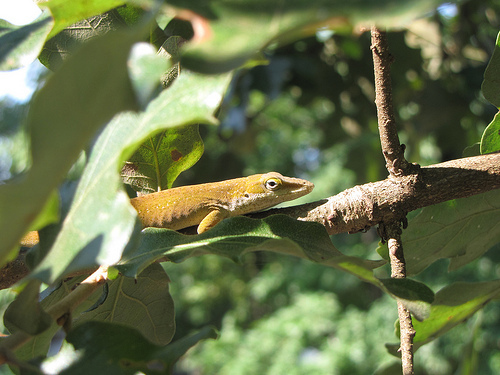

In [6]:
from PIL import Image

image = Image.open("tutorials/lizard.jpg")
image

In [7]:
# Use torchvision ViT-B/16 and apply LXT monkey patch
# This is required so masking targets attention heads (not conv/linear fallbacks).


# Apply monkey patches for attention-aware relevance
monkey_patch(vision_transformer, verbose=True)
monkey_patch_zennit(verbose=True)



# Create a ViT-B/16 model (pretrained weights not required for this test)
try:
    weights = vision_transformer.ViT_B_16_Weights.IMAGENET1K_V1
    transformer_model = vision_transformer.vit_b_16(weights=weights).to(device)
    transformer_model.eval()
    print("✓ ViT-B/16 model created successfully")

    # Transform the PIL image to tensor before passing to model
    transform = T.Compose([T.Resize(256), T.CenterCrop(224), T.ToTensor()])
    image_tensor = transform(image)
    
    output = transformer_model(image_tensor.unsqueeze(0).to(device))
    print(f"✓ Forward pass successful: output shape {output.shape}")
except Exception as e:
    print(f"✗ Error creating ViT-B/16: {type(e).__name__}: {e}")
    import traceback
    traceback.print_exc()

Patched GELU
Patched LayerNorm
Patched MultiheadAttention
Patched Zennit BasicHook's forward
Patched Zennit BasicHook's backward
✓ ViT-B/16 model created successfully
✓ Forward pass successful: output shape torch.Size([1, 1000])


In [8]:
# Define composite with rules only for Conv2d and Linear, NOT MultiheadAttention
# This avoids conflicts with LXT monkey patches on attention layers
composite = LayerMapComposite([
    (nn.Conv2d, z_rules.Gamma(0.25)),
    (nn.Linear, z_rules.Gamma(0.1)),
])

# Use AttentionAttribution for transformer models
attribution = AttentionAttribution(transformer_model)

In [9]:
ahc = AttentionHeadConcept()
layer_names = get_layer_names(transformer_model, [nn.MultiheadAttention])
layer_map = {name: ahc for _, name in enumerate(layer_names)}
print(f"✓ Layer map created with {len(layer_map)} layers")

# separate normalization from resizing for plotting purposes later
transform = T.Compose([T.Resize(256), T.CenterCrop(224), T.ToTensor()])
preprocessing =  T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

data_path = "ImageNet_data"
# 1. Load the full dataset
imagenet_full = torchvision.datasets.ImageNet(data_path, transform=transform, split="val")  
# 2. Create a subset of just the first few images
imagenet_subset = Subset(imagenet_full, range(64))

✓ Layer map created with 12 layers


In [10]:
fv_path = "VIT_B16_ImageNet"
def vit_heatmap_modifier(data, on_device=None):
    heatmap = data.grad.detach()
    heatmap = heatmap.to(on_device) if on_device else heatmap
    return torch.sum(heatmap, dim=1)
attribution.heatmap_modifier = vit_heatmap_modifier

fv = FeatureVisualization(attribution, imagenet_subset, layer_map, preprocess_fn=preprocessing, path=fv_path)

In [9]:
saved_files = fv.run(None, 0, len(imagenet_subset), 32, 100)

NameError: name 'fv' is not defined

In [7]:
from zipfile import Path

# Build relevance index
saved_files = fv.run(
    composite=None,
    data_start=0,
    data_end=len(imagenet_subset),
    batch_size=4,
    checkpoint=64,
    on_device="cpu",
)

# Confirm expected file path
target_file = fv_path + "RelMax_sum_normed/encoder.layer.encoder_layer_11_data.npy"
print(f"Expected index file: {target_file}")
# print(f"Exists: {Path(target_file).exists()}")


Running Analysis...


100%|██████████| 16/16 [00:30<00:00,  1.88s/it]


100%|██████████| 24/24 [00:00<00:00, 1534.83it/s]

Expected index file: VIT_B16_ImageNetRelMax_sum_normed/encoder.layer.encoder_layer_11_data.npy


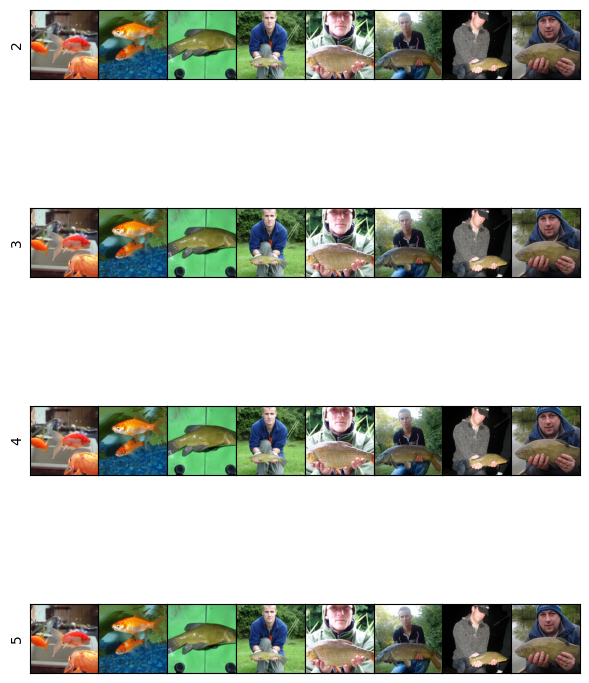

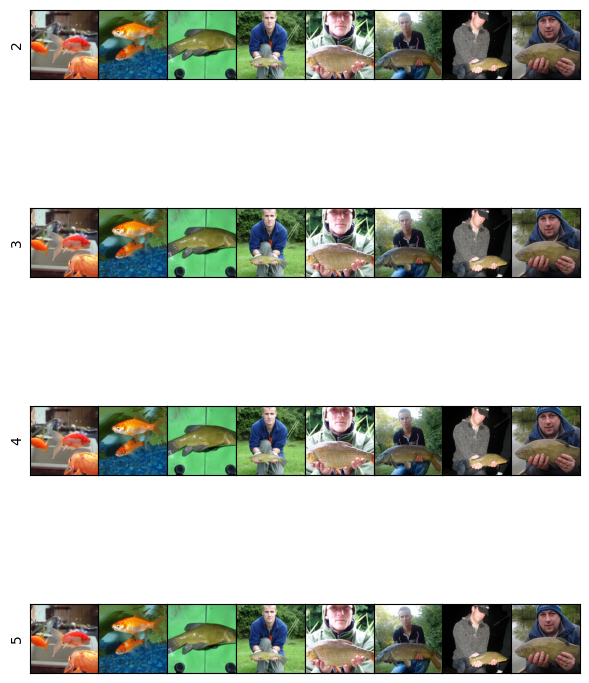

In [25]:
ref_c = fv.get_max_reference([2, 3, 4, 5], "encoder.layers.encoder_layer_11", "relevance", (0, 8), composite=None, plot_fn=None)

plot_grid(ref_c, figsize=(6, 9))

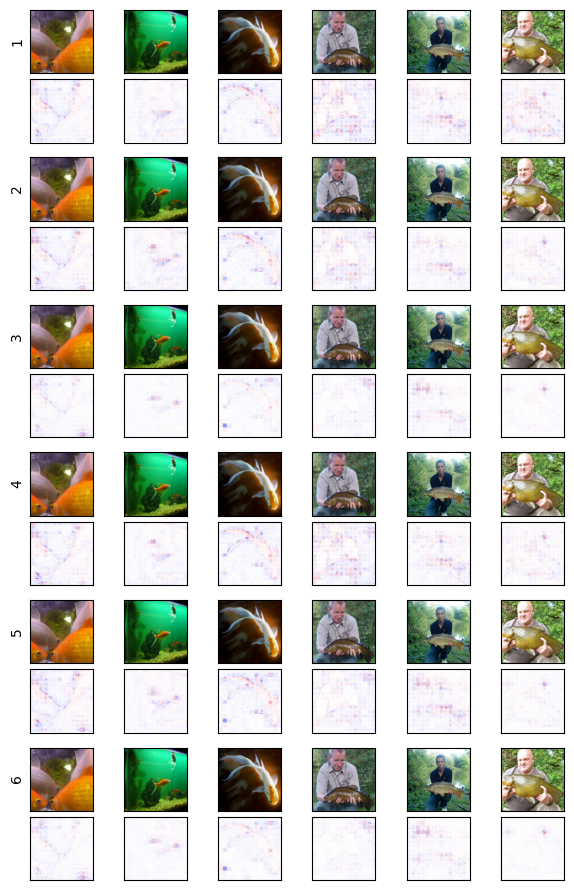

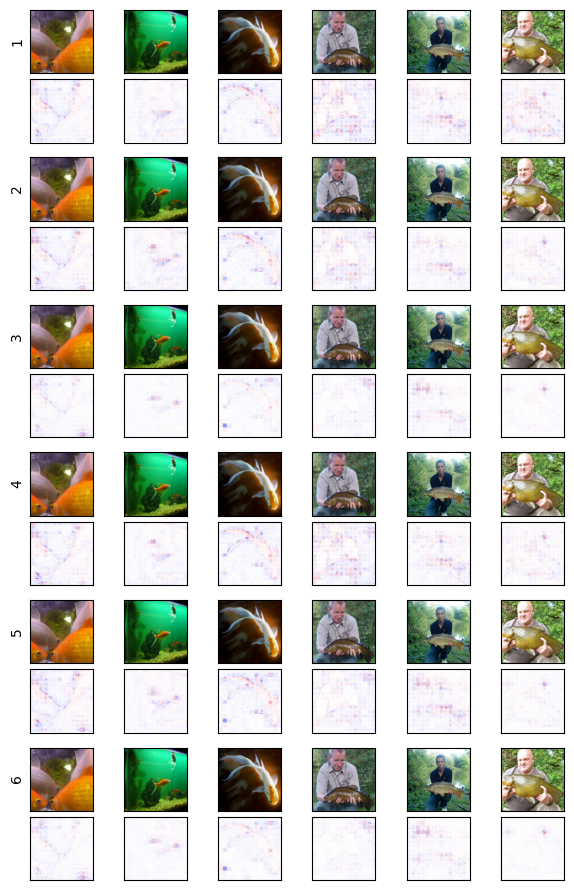

In [11]:
%matplotlib inline
from crp.image import plot_grid

ref_c = fv.get_max_reference(concept_ids=[1, 2, 3, 4, 5, 6], layer_name="encoder.layers.encoder_layer_11", mode="relevance", r_range=(0, 6),composite=composite)

plot_grid(ref_c, figsize=(6, 9), padding=False)

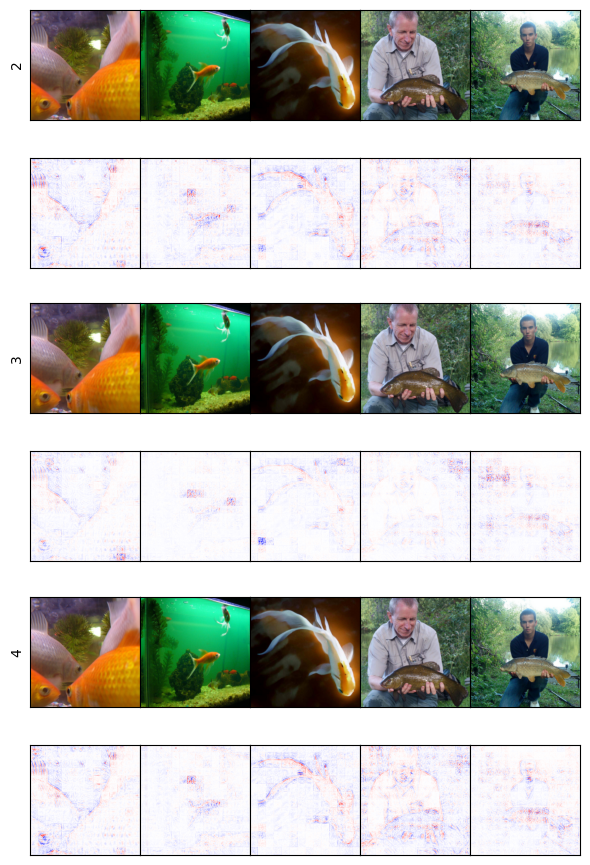

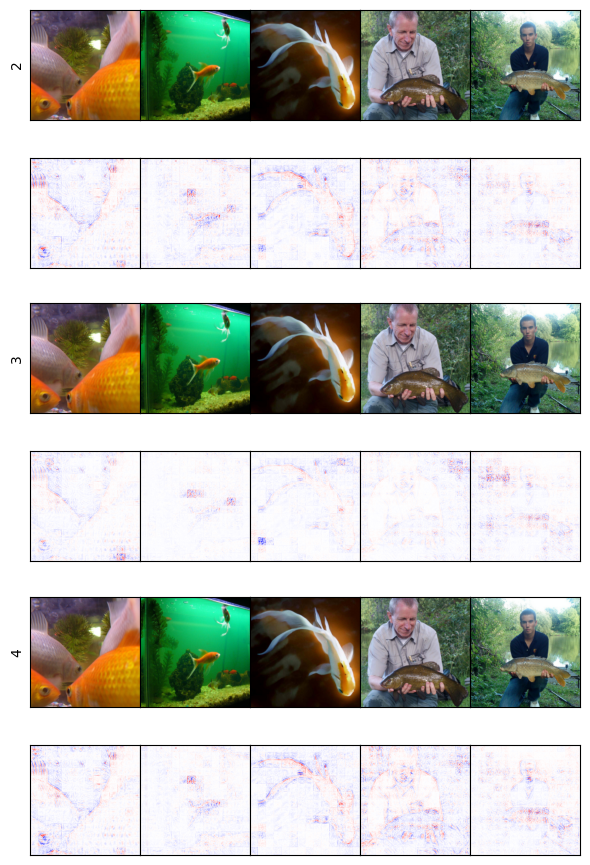

In [ ]:
%matplotlib inline
from crp.image import plot_grid

ref_c = fv.get_max_reference(concept_ids=[2, 3, 4], layer_name="encoder.layers.encoder_layer_11", mode="relevance", r_range=(0, 5),composite=composite)

plot_grid(ref_c, figsize=(6, 9), padding=False)

In [26]:
%ll VIT_B16_ImageNet/RelMax_sum_normed/encoder*11*.npy

6603.67s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


-rw-r--r-- 1 satou 63168 26. úno 22.38 VIT_B16_ImageNet/RelMax_sum_normed/encoder_layer_11_data.npy
-rw-r--r-- 1 satou 31648 26. úno 22.38 VIT_B16_ImageNet/RelMax_sum_normed/encoder_layer_11_rel.npy
-rw-r--r-- 1 satou 63168 26. úno 22.38 VIT_B16_ImageNet/RelMax_sum_normed/encoder_layer_11_rf.npy
-rw-r--r-- 1 satou 63168 28. úno 16.07 VIT_B16_ImageNet/RelMax_sum_normed/encoder.layers.encoder_layer_11.self_attention_data.npy
-rw-r--r-- 1 satou 31648 28. úno 16.07 VIT_B16_ImageNet/RelMax_sum_normed/encoder.layers.encoder_layer_11.self_attention_rel.npy
-rw-r--r-- 1 satou 63168 28. úno 16.07 VIT_B16_ImageNet/RelMax_sum_normed/encoder.layers.encoder_layer_11.self_attention_rf.npy


In [16]:
heat_data = np.load("VGG16_ImageNet/RelMax_sum_normed/features.40_data.npy")
display(heat_data.shape)
heat_rel = np.load("VGG16_ImageNet/RelMax_sum_normed/features.40_rel.npy")
display(heat_rel.shape)
heat_rf = np.load("VGG16_ImageNet/RelMax_sum_normed/features.40_rf.npy")
display(heat_rf.shape)

(10, 512)

(10, 512)

(10, 512)

In [17]:
heat_data = np.load("VIT_B16_ImageNet/RelMax_sum_normed/encoder_layer_11_data.npy")
display(heat_data.shape)
heat_rel = np.load("VIT_B16_ImageNet/RelMax_sum_normed/encoder_layer_11_rel.npy")
display(heat_rel.shape)
heat_rf = np.load("VIT_B16_ImageNet/RelMax_sum_normed/encoder_layer_11_rf.npy")
display(heat_rf.shape)

(40, 197)

(40, 197)

(40, 197)

In [15]:
heat_data = np.load("VIT_B16_ImageNet/RelMax_sum_normed/encoder.layers.encoder_layer_11.self_attention_data.npy")
display(heat_data.shape)
heat_rel = np.load("VIT_B16_ImageNet/RelMax_sum_normed/encoder.layers.encoder_layer_11.self_attention_rel.npy")
display(heat_rel.shape)
heat_rf = np.load("VIT_B16_ImageNet/RelMax_sum_normed/encoder.layers.encoder_layer_11.self_attention_rf.npy")
display(heat_rf.shape)

(40, 197)

(40, 197)

(40, 197)

In [27]:
repr(heat)

'array([[62, 62, 62, ..., 62, 62, 62],\n       [63, 63, 63, ..., 63, 63, 63],\n       [38, 38, 38, ..., 38, 38, 38],\n       ...,\n       [24, 24, 24, ..., 24, 24, 24],\n       [52, 52, 52, ..., 52, 52, 52],\n       [15, 15, 15, ..., 15, 15, 15]])'

In [6]:
# Set up layer map for transformer attention heads
ahc = AttentionHeadConcept()

# Find all attention layers inside ViT
attn_layer_names = get_layer_names(transformer_model, [nn.MultiheadAttention])
print(f"All attention layers found ({len(attn_layer_names)} total):")
for i, name in enumerate(attn_layer_names):
    print(f"  {i}: {name}")

# Use the LAST attention layer (encoder_layer_11.self_attention)
# ViT-B/16 has 12 encoder blocks (0-11), we want the last one
if attn_layer_names:
    last_attn_layer = attn_layer_names[-1]
    print(f"\n✓ Using last attention layer: {last_attn_layer}")
    
    # ViT-B/16 has 12 attention heads (hidden_dim=768, head_dim=64 → 768/64=12)
    num_heads = 12
    print(f"  Number of heads: {num_heads}")
    print(f"  Head dimension: 64")
    
    # Create layer map (map each attention layer to AttentionHeadConcept)
    transformer_layer_map = {layer: ahc for layer in attn_layer_names}
    
    # Create attribution object for transformers
    try:
        transformer_attribution = AttentionAttribution(transformer_model, device=device)
        print("✓ AttentionHeadAttribution created successfully")
    except Exception as e:
        print(f"✗ Error creating AttentionHeadAttribution: {type(e).__name__}: {e}")
        import traceback
        traceback.print_exc()
else:
    print("✗ No attention layers found")
    last_attn_layer = None

Attention layers found: ['attn']
Layer map created: {'attn': <crp.concepts.AttentionHeadConcept object at 0x7fe9e38ad690>}
✓ AttentionHeadAttribution created successfully


## Section 5: Run Masking with AttentionHeadAttribution and Capture Errors

In [ ]:
# Define conditions: which attention heads to analyze
# We must include "y" (output) with target class

if not attn_layer_names:
    print("✗ Skipping masking test because no attention layers were found.")
else:
    attn_layer_name = attn_layer_names[0]
    print(f"Using attention layer: {attn_layer_name}")

    transformer_conditions = [
        {attn_layer_name: [0], "y": [0]},        # Head 0 for class 0
        {attn_layer_name: [1], "y": [0]},        # Head 1 for class 0
        {attn_layer_name: [0, 1], "y": [0]},     # Heads 0 and 1 for class 0
    ]

    print("Testing AttentionHeadAttribution.generate with ViT-B/16...")
    print(f"Conditions: {transformer_conditions}")

    # Create dummy input image
    dummy_img = torch.randn(1, 3, 224, 224, device=device, requires_grad=True)
    print(f"Input shape: {dummy_img.shape} [batch=1, 3, 224, 224]")

    try:
        results_transformer = []
        for i, attr_result in enumerate(transformer_attribution.generate(
            dummy_img,
            transformer_conditions,
            composite=None,
            batch_size=2,
            verbose=False
        )):
            print(f"✓ Batch {i+1}:")
            print(f"    heatmap shape: {attr_result.heatmap.shape}")
            print(f"    prediction shape: {attr_result.prediction.shape}")
            if attr_result.activations:
                print(f"    activations keys: {list(attr_result.activations.keys())}")
            results_transformer.append(attr_result)
        
        print("\n✓ AttentionHeadAttribution.generate completed successfully!")
        
    except Exception as e:
        print(f"\n✗ Error during AttentionHeadAttribution.generate:")
        print(f"  Type: {type(e).__name__}")
        print(f"  Message: {e}")
        import traceback
        print("\nFull traceback:")
        traceback.print_exc()

    print("\nTesting AttentionFeatureVisualization.run (minimal smoke test)...")

    class TinyImageNetLikeDataset(Dataset):
        def __init__(self, n=4, num_classes=1000):
            self.n = n
            self.num_classes = num_classes

        def __len__(self):
            return self.n

        def __getitem__(self, idx):
            x = torch.randn(3, 224, 224)
            y = idx % self.num_classes
            return x, y

    tiny_dataset = TinyImageNetLikeDataset(n=4, num_classes=1000)
    afv_path = "ViT_Attention_FeatureVisualization_Test"

    try:
        afv = FeatureVisualization(
            attribution=transformer_attribution,
            dataset=tiny_dataset,
            layer_map=transformer_layer_map,
            preprocess_fn=lambda x: x,
            path=afv_path,
            device=device,
        )

        # Keep it tiny to validate integration only
        saved_files = afv.run(
            composite=None,
            data_start=0,
            data_end=2,
            batch_size=1,
            checkpoint=1,
            on_device="cpu",
        )

        print("✓ AttentionFeatureVisualization.run completed")
        print(f"Saved checkpoint keys: {list(saved_files.keys())}")
    except Exception as e:
        print(f"✗ AttentionFeatureVisualization.run failed: {type(e).__name__}: {e}")
        import traceback
        traceback.print_exc()

Testing AttentionHeadAttribution.generate with transformer...
Conditions: [{'attn': [0]}, {'attn': [1]}, {'attn': [0, 1]}]
Input shape: torch.Size([1, 16, 3]) [batch=1, seq_len=16, features=3]

✗ Error during AttentionHeadAttribution.generate:
  Type: ValueError
  Message: Either y in 'conditions' or 'start_layer' or 'init_rel' must be defined.

Full traceback:


Traceback (most recent call last):
  File "/tmp/ipykernel_37365/1695330580.py", line 18, in <module>
    for i, attr_result in enumerate(transformer_attribution.generate(
  File "/home/satou/Projects/crp-experimenting/crp/attribution.py", line 370, in generate
    self._check_arguments(data, conditions, start_layer, exclude_parallel, init_rel)
  File "/home/satou/Projects/crp-experimenting/crp/attribution.py", line 151, in _check_arguments
    raise ValueError(
ValueError: Either y in 'conditions' or 'start_layer' or 'init_rel' must be defined.


## Summary

This notebook demonstrates:

1. **batch_size Analysis**: The `batch_size` variable in `CondAttribution.generate` is NOT unused. It is:
   - Used for computing the number of batches
   - Slicing conditions into batches
   - Reassigned in the final batch to handle uneven splits
   - Used to slice output tensors properly

2. **Transformer Feature Visualization Setup (ViT-B/16 + LXT monkey patch)**:
   - Uses torchvision ViT-B/16
   - Applies `monkey_patch(vision_transformer)` and `monkey_patch_zennit()`
   - Targets attention heads via `AttentionHeadConcept` and `AttentionHeadAttribution`

3. **Error Capture**: Any errors from attention-head masking are displayed above with full tracebacks for debugging.